# STEP01. 환경 설정 및 구글 드라이브 마운트

### 01-1. 기본경로 설정

In [1]:
# 기본 경로 설정
base_path = '/content/drive/MyDrive/AIduo_dev/Project'

### 01-2. 구글 드라이브 마운트 및 필수 라이브러리 설치

In [2]:
# (주의: 코랩 런타임을 새로 시작할 때마다 가장 먼저 실행해야 합니다)
!pip install basicsr==1.4.2 thop einops rasterio geopandas pandas opencv-python tqdm timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 13.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 27.1 MB/s eta 0:00:00
  Created wheel for basicsr: filename=basicsr-1.4.2-py3-none-any.whl size=214817 sha256=0c6e4b47b8ba85e88708dd359722d24a0effb93c6c8cfd587a76c6a6a2b5aa3b
  Stored in directory: /root/.cache/pip/wheels/9a/e3/e4/58f29bfabb622dd40b6d9839318ce5bf092062b81ca3aa19ea
Successfully built basicsr


#### 필수 모듈 Import

In [3]:
import os
import sys
import cv2
import time
import shutil
import rasterio
import pandas as pd
import numpy as np
import torch
import timm
import torchvision.transforms as transforms
from datetime import datetime
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

#### 구글 드라이브 마운트

In [11]:
from google.colab import drive
drive.mount('/content/drive')

weights_path = os.path.join(base_path, 'train_data/weights')

# 입출력 경로 설정
dir_now = 'Inference_data/2026-06-24'
dir_input = os.path.join(base_path, dir_now, '0_original_input')
dir_base_png = os.path.join(base_path, dir_now, '1_base_png')
dir_routing = os.path.join(base_path, dir_now, '2_routing')
dir_final = os.path.join(base_path, dir_now, '3_final_refined') # 최종 결과물

for p in [dir_input, dir_base_png, dir_routing, dir_final]:
    os.makedirs(p, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 사용 장치: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 사용 장치: cuda


# STEP 02. 모델 로드 함수 정의 (A, B, C, D 모델)

## STEP 02-1. 모델 함수 정의

In [12]:
import os

# 폴더 생성
module_dir = '/content/drive/MyDrive/AIduo_dev/Project/aiduo_2026'
os.makedirs(module_dir, exist_ok=True)

### [Model A] 해상도 분류 (DINOv3)

In [ ]:
# 1. 드라이브 마운트 및 모듈 저장 폴더 생성
import os
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/AIduo_dev/Project'
save_dir = os.path.join(base_path, 'aiduo_2026')
os.makedirs(save_dir, exist_ok=True)

print(f"📦 모듈 저장 경로가 준비되었습니다: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 모듈 저장 경로가 준비되었습니다: /content/drive/MyDrive/AIduo_dev/Project/aiduo_2026


In [ ]:
%%writefile /content/drive/MyDrive/AIduo_dev/Project/aiduo_2026/dinov3_model.py
import os
import torch
import torch.nn as nn
import timm
from torchvision import transforms

# ============================================================
# 1. 해상도 및 클래스 인덱스 매핑 정의
# ============================================================
RESOLUTION_MAP = {
    '0.5M': 0,
    '1M': 1,
    '2M': 2,
    '3M': 3,
    '8M': 4
}
IDX_TO_RES = {v: k for k, v in RESOLUTION_MAP.items()}

# ============================================================
# 2. DINOv3 전용 이미지 전처리 트랜스폼 헬퍼
# ============================================================
def get_dinov3_transform(img_size=224):
    """
    DINOv3 모델 입력 규격에 맞춘 전처리 Pipeline을 반환합니다.
    """
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

# ============================================================
# 3. DINOv3 해상도 분류 모델 클래스
# ============================================================
class DINOv3ResolutionClassifier(nn.Module):
    def __init__(self, model_name='vit_large_patch16_dinov3', num_classes=5, pretrained=False):
        super().__init__()
        # timm 라이브러리를 활용하여 DINOv3 백본에 5개 해상도 분류용 Head 결합
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

# ============================================================
# 4. 가중치 로드 및 모델 초기화 통합 함수
# ============================================================
def load_dinov3_model(checkpoint_path, model_name='vit_large_patch16_dinov3', device='cuda'):
    """
    지정된 체크포인트 가중치를 안전하게 로드하여 추론 모드의 DINOv3 모델을 반환합니다.
    """
    model = DINOv3ResolutionClassifier(model_name=model_name, num_classes=5, pretrained=False)

    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)

        # 딕셔너리 포장 형태(상태 파일) 혹은 순수 state_dict 대응
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        elif isinstance(checkpoint, dict) and 'model' in checkpoint:
            state_dict = checkpoint['model']
        else:
            state_dict = checkpoint

        # 💡 [핵심 수정] 가중치 키(Key) 불일치 자동 맵핑 보정
        fixed_state_dict = {}
        for k, v in state_dict.items():
            # 저장된 체크포인트 키에 'model.' 접두사가 없다면 강제로 붙여서 아키텍처와 짝을 맞춤
            if not k.startswith('model.'):
                fixed_state_dict[f'model.{k}'] = v
            else:
                fixed_state_dict[k] = v

        # 수정한 state_dict로 로드
        model.load_state_dict(fixed_state_dict, strict=True)
        print(f"✅ [DINOv3] 가중치 로드 성공: {os.path.basename(checkpoint_path)}")
    else:
        print(f"⚠️ [DINOv3] 경고: 가중치 파일을 찾을 수 없어 빈 구조만 초기화합니다. 경로: {checkpoint_path}")

    model.to(device)
    model.eval()
    return model

Overwriting /content/drive/MyDrive/AIduo_dev/Project/aiduo_2026/dinov3_model.py


 ### [Model B] 3M -> 2M SR (RRDB)

In [ ]:
%%writefile /content/drive/MyDrive/AIduo_dev/Project/aiduo_2026/rrdb_model_vr2.py
import torch
import torch.nn as nn

class ResidualDenseBlock_5C(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.conv1 = nn.Conv2d(nf, gc, 3, 1, 1)
        self.conv2 = nn.Conv2d(nf+gc, gc, 3, 1, 1)
        self.conv3 = nn.Conv2d(nf+gc*2, gc, 3, 1, 1)
        self.conv4 = nn.Conv2d(nf+gc*3, gc, 3, 1, 1)
        self.conv5 = nn.Conv2d(nf+gc*4, nf, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat([x, x1], 1)))
        x3 = self.lrelu(self.conv3(torch.cat([x, x1, x2], 1)))
        x4 = self.lrelu(self.conv4(torch.cat([x, x1, x2, x3], 1)))
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], 1))
        return x + x5 * 0.2

class RRDB(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.rdb1 = ResidualDenseBlock_5C(nf, gc)
        self.rdb2 = ResidualDenseBlock_5C(nf, gc)
        self.rdb3 = ResidualDenseBlock_5C(nf, gc)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return x + out * 0.2

class RRDBNetA2V5B(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_first = nn.Conv2d(3, 64, 3, 1, 1)
        self.trunk = nn.Sequential(*[RRDB() for _ in range(8)])
        self.trunk_conv = nn.Conv2d(64, 64, 3, 1, 1)
        self.hr_conv = nn.Conv2d(64, 64, 3, 1, 1)
        self.conv_last = nn.Conv2d(64, 3, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        fea = self.conv_first(x)
        trunk = self.trunk_conv(self.trunk(fea))
        fea = fea + trunk
        out = self.conv_last(self.lrelu(self.hr_conv(fea)))
        return out.clamp(0, 1)

Overwriting /content/drive/MyDrive/AIduo_dev/Project/aiduo_2026/rrdb_model_vr2.py


### [Model C] 2M -> 0.5M SR (HAT)

In [ ]:
import os
import shutil

base_path = '/content/drive/MyDrive/AIduo_dev/Project'
# 원본 hat 폴더 경로
src_hat_folder = os.path.join(base_path, 'hat_model_train_test_file/hat')
# 목적지 내부에 'hat' 이라는 서브 패키지 폴더를 명시하여 생성
dst_hat_folder = os.path.join(base_path, 'aiduo_2026/hat')

if not os.path.exists(src_hat_folder):
    print(f"❌ 원본 hat 폴더를 찾을 수 없습니다: {src_hat_folder}")
else:
    os.makedirs(dst_hat_folder, exist_ok=True)
    try:
        # 패키지 명칭을 유지하며 통째로 복사 (Merge)
        shutil.copytree(src_hat_folder, dst_hat_folder, dirs_exist_ok=True)
        print(f"✅ HAT 패키지가 'aiduo_2026/hat' 구조로 완벽하게 재정렬 복사되었습니다!")
        print(f"📊 포함된 하위 구조 확인: {os.listdir(dst_hat_folder)}")
    except Exception as e:
        print(f"❌ 복사 중 오류 발생: {e}")

✅ HAT 패키지가 'aiduo_2026/hat' 구조로 완벽하게 재정렬 복사되었습니다!
📊 포함된 하위 구조 확인: ['train.py', '__init__.py', 'requirements.txt', 'archs', 'models', 'data', '__pycache__']


### [Model D] 0.5M Refinement (CycleGAN Generator A->B)

In [14]:
# 1. 드라이브 마운트 및 폴더 확인 (이미 활성화되어 있다면 생략 가능)
import os
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/AIduo_dev/Project'
save_dir = os.path.join(base_path, 'aiduo_2026')
os.makedirs(save_dir, exist_ok=True)

print(f"📦 CycleGen 모듈을 저장할 경로: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 CycleGen 모듈을 저장할 경로: /content/drive/MyDrive/AIduo_dev/Project/aiduo_2026


In [15]:
%%writefile /content/drive/MyDrive/AIduo_dev/Project/aiduo_2026/cycleGen_model.py
import os
import torch
import torch.nn as nn

# ============================================================
# 1. CycleGAN용 Residual Block 정의
# ============================================================
class CycleGANResidualBlock(nn.Module):
    def __init__(self, features):
        super(CycleGANResidualBlock, self).__init__()
        # 체크포인트 구조에 맞춰 bias=True로 설정
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(features, features, kernel_size=3, padding=0, bias=True),
            nn.InstanceNorm2d(features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(features, features, kernel_size=3, padding=0, bias=True),
            nn.InstanceNorm2d(features)
        )

    def forward(self, x):
        return x + self.block(x)

# ============================================================
# 2. CycleGAN Generator 아키텍처 (체크포인트 완전 호환 버전)
# ============================================================
class CycleGANGenerator(nn.Module):
    def __init__(self, input_nc=3, output_nc=3, num_residual_blocks=9):
        super(CycleGANGenerator, self).__init__()

        # [0~3] 초기 컨볼루션 블록
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(input_nc, 64, kernel_size=7, padding=0, bias=True),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        ]

        # [4~9] Downsampling (특징 맵 축소)
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            model += [
                nn.Conv2d(in_features, out_features, kernel_size=3, stride=2, padding=1, bias=True),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features = in_features * 2

        # [10~18] 핵심 Residual Blocks
        for _ in range(num_residual_blocks):
            model += [CycleGANResidualBlock(in_features)]

        # [19~26] Upsampling (격자무늬 깨짐 방지를 위한 Upsample + Conv2d 조합)
        out_features = in_features // 2
        for _ in range(2):
            model += [
                nn.Upsample(scale_factor=2, mode='nearest'),
                nn.Conv2d(in_features, out_features, kernel_size=3, stride=1, padding=1, bias=True),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features = in_features // 2

        # [27~29] 최종 출력 레이어 (28번 인덱스 Conv2d 매핑 완료)
        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, output_nc, kernel_size=7, padding=0, bias=True),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

# ============================================================
# 3. 원터치 가중치 로드 및 추론 초기화 헬퍼 함수
# ============================================================
def load_cyclegan_model(checkpoint_path, device='cuda'):
    model = CycleGANGenerator(input_nc=3, output_nc=3, num_residual_blocks=9)

    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)

        # 키 파싱
        if isinstance(checkpoint, dict):
            if 'model_state_dict' in checkpoint:
                state_dict = checkpoint['model_state_dict']
            elif 'state_dict' in checkpoint:
                state_dict = checkpoint['state_dict']
            elif 'netG_A2B' in checkpoint:
                state_dict = checkpoint['netG_A2B']
            else:
                state_dict = checkpoint
        else:
            state_dict = checkpoint

        model.load_state_dict(state_dict, strict=True)
        print(f"✅ [CycleGen] 가중치 로드 완료: {os.path.basename(checkpoint_path)}")
    else:
        print(f"⚠️ [CycleGen] 경고: 가중치 파일이 존재하지 않습니다. 경로: {checkpoint_path}")

    model.to(device)
    model.eval()
    return model

Overwriting /content/drive/MyDrive/AIduo_dev/Project/aiduo_2026/cycleGen_model.py


## STEP 02-2. 모델 함수 로드

In [16]:
# =====================================================================
# [핵심 해결책 1] torchvision 호환성 문제 우회 (Monkey Patch)
# basicsr 1.4.2가 최신 torchvision에서 삭제된 모듈을 찾지 않도록 가짜 모듈을 주입합니다.
# 반드시 basicsr이나 hat 모듈을 import 하기 '전'에 실행되어야 합니다.
# =====================================================================
import torchvision.transforms.functional as F_t
class DummyFunctionalTensor:
    pass
dummy = DummyFunctionalTensor()
dummy.rgb_to_grayscale = F_t.rgb_to_grayscale
sys.modules['torchvision.transforms.functional_tensor'] = dummy
print("✅ torchvision.transforms.functional_tensor 우회 패치 완료")


✅ torchvision.transforms.functional_tensor 우회 패치 완료


In [17]:
import sys
import os
import torch
import timm # DINOv3용

target_module_path = os.path.join(base_path, 'aiduo_2026')

if target_module_path not in sys.path:
    # 모듈 우선순위를 높이기 위해 insert(0, ...)를 사용할 수도 있지만,
    # 일반적으로 append로 충분히 인식됩니다.
    sys.path.append(target_module_path)
    print(f"✔️ 통합 모듈 경로 등록 완료: {target_module_path}")
else:
    print(f"✔️ 통합 모듈 경로가 이미 등록되어 있습니다: {target_module_path}")

# 현재 등록된 전체 커스텀 경로 상태 확인 (디버깅용)
print("\n[현재 sys.path 내 프로젝트 관련 경로 목록]")
for p in sys.path:
    if 'AIduo_dev' in p:
        print(f" - {p}")

✔️ 통합 모듈 경로가 이미 등록되어 있습니다: /content/drive/MyDrive/AIduo_dev/Project/aiduo_2026

[현재 sys.path 내 프로젝트 관련 경로 목록]
 - /content/drive/MyDrive/AIduo_dev/Project/aiduo_2026


In [21]:
import os
import sys
import torch
import timm

# 1. 경로 설정
base_path = '/content/drive/MyDrive/AIduo_dev/Project'
module_dir = os.path.join(base_path, 'aiduo_2026')
if module_dir not in sys.path:
    sys.path.append(module_dir)

# 2. 임포트 (새로 생성한 클래스명 적용)
from dinov3_model import load_dinov3_model, get_dinov3_transform, IDX_TO_RES
from rrdb_model_vr2 import RRDBNetA2V5B as RRDBNet # 변경됨
from cycleGen_model import load_cyclegan_model

weights_path = os.path.join(base_path, 'train_data/weights')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_all_models():
    models_dict = {}
    print("🔄 [파이프라인] 전체 AI 전문가 모델 순차 로드 시작...")

    # [Model A] DINOv3 해상도 판별
    a_weight = os.path.join(weights_path, 'classified_DINOv3-Large/best_checkpoint.pth')
    models_dict['A_clf'] = load_dinov3_model(a_weight, model_name='vit_large_patch16_dinov3', device=device)
    models_dict['A_transform'] = get_dinov3_transform(img_size=224)

    # ------------------------------------------------------------
    # [Model B] 3M → 2M SR (RRDBNet - 수정됨)
    # ------------------------------------------------------------
    # 체크포인트 형상(48채널, 23개 블록)에 맞게 초기화
    model_b = RRDBNet()
    b_weight = os.path.join(weights_path, 'SRtoHR_byRRDB/A2_v5b_rrdbnet_best.pth')

    if os.path.exists(b_weight):
        checkpoint = torch.load(b_weight, map_location=device)

        # pth 파일이 dict 형태(체크포인트)일 경우와 순수 가중치일 경우 모두 대응
        state_dict = checkpoint['model_state_dict'] if (isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint) else checkpoint

        model_b.load_state_dict(state_dict)
        print(f"✅ Model B (RRDB 2M) 가중치 매핑 성공: {os.path.basename(b_weight)}")
    else:
        print(f"⚠️ [경고] Model B 가중치 파일 누락: {b_weight}")

    model_b.to(device).eval()
    models_dict['B'] = model_b

    # ------------------------------------------------------------
    # [Model C] 2M → 0.5M SR 작업 (HAT)
    # ------------------------------------------------------------
    c_weight = os.path.join(weights_path, 'SRtoHR_byGOIThat/net_g_270000.pth')

    if os.path.exists(c_weight):
        # 1. 모델 레지스트리에서 HAT 가져오기 및 초기화 (성공 코드 기반)
        from basicsr.utils.registry import ARCH_REGISTRY
        import hat.archs.hat_arch  # HAT 모델 자동 등록

        HAT = ARCH_REGISTRY.get("HAT")
        if HAT is None:
            raise ImportError("❌ HAT 모델을 ARCH_REGISTRY에서 찾을 수 없습니다.")

        # HAT 모델 아키텍처 초기화
        model_c = HAT(
            upscale=4,
            in_chans=3,
            img_size=64,
            window_size=16,
            compress_ratio=3,
            sqz_ch=30,
            mlp_ratio=2,
            depths=[6, 6, 6, 6, 6, 6],
            embed_dim=180,
            num_heads=[6, 6, 6, 6, 6, 6],
            attn_drop_rate=0.,
            drop_path_rate=0.1,
            use_checkpoint=False,
            upsampler="pixelshuffle",
            resi_connection="1conv"
        ).to(device)

        # 2. 가중치 로드
        checkpoint = torch.load(c_weight, map_location=device)
        state_dict = checkpoint['params_ema'] if 'params_ema' in checkpoint else checkpoint.get('params', checkpoint)

        # 파라미터 키 확인
        keyname = 'params_ema' if 'params_ema' in checkpoint else 'params'
        # # 💡 [추가된 핵심 로직] 에러를 유발하는 불필요한 키들을 state_dict에서 직접 제거
        # keys_to_remove = [
        #     "conv_before_upsample.0.weight", "conv_before_upsample.0.bias",
        #     "upsample.0.weight", "upsample.0.bias",
        #     "upsample.2.weight", "upsample.2.bias",
        #     "conv_last.weight", "conv_last.bias"
        # ]

        # for k in keys_to_remove:
        #     if k in state_dict:
        #         del state_dict[k]

        # 💡 핵심 수정: strict=False 로 변경하여 불필요한 키 에러 무시
        model_c.load_state_dict(checkpoint[keyname], strict=False)
        model_c.eval()
        print(f"✅ Model C (HAT 0.5M) 가중치 로드 및 매핑 성공 (strict=False): {os.path.basename(c_weight)}")
        models_dict['C'] = model_c
    else:
        print(f"⚠️ Model C (HAT 0.5M) 가중치 파일이 없습니다: {c_weight}")

    # ------------------------------------------------------------
    # [Model D] 0.5M 해상도 및 디테일 정제 개선 (CycleGAN Generator)
    # ------------------------------------------------------------
    d_weight = os.path.join(weights_path, 'SRtoHR_byCycleGen_8/best_G_AB.pth')
    model_d = load_cyclegan_model(d_weight, device=device)
    models_dict['D'] = model_d

    print("\n🚀 [시스템] 모든 전문가 추론 모델 파이프라인 빌드 완료.")
    return models_dict

# 파이프라인 관리 딕셔너리 생성
models_dict = load_all_models()

🔄 [파이프라인] 전체 AI 전문가 모델 순차 로드 시작...
✅ [DINOv3] 가중치 로드 성공: best_checkpoint.pth
✅ Model B (RRDB 2M) 가중치 매핑 성공: A2_v5b_rrdbnet_best.pth
✅ Model C (HAT 0.5M) 가중치 로드 및 매핑 성공 (strict=False): net_g_270000.pth
✅ [CycleGen] 가중치 로드 완료: best_G_AB.pth

🚀 [시스템] 모든 전문가 추론 모델 파이프라인 빌드 완료.


# STEP 03. 데이터 입력 및 PNG 변환 파이프라인

In [22]:
# 2. 이미지 입력 처리 (업로드 기능 포함)
from google.colab import files
import rasterio
import numpy as np
import cv2
import shutil
from datetime import datetime

upload_mode = True # 업로드를 원할 경우 True로 유지

if upload_mode:
    print("이미지를 업로드해주세요.")
    uploaded = files.upload()
    timestamp = datetime.now().strftime('%Y%m%d%H%M%S')
    upload_dir = os.path.join(dir_input, f'upload_{timestamp}')
    os.makedirs(upload_dir, exist_ok=True)
    for filename in uploaded.keys():
        shutil.move(filename, os.path.join(upload_dir, filename))
    target_input_dir = upload_dir
else:
    # Inference_data/0_original_input 폴더 안의 특정 폴더를 선택하거나 전체 사용
    target_input_dir = dir_input

print(f"입력 경로: {target_input_dir}")

이미지를 업로드해주세요.


Saving 4xSatSR_00211.tif to 4xSatSR_00211.tif
Saving SEN2NAIPv2unet_04382.tif to SEN2NAIPv2unet_04382.tif
Saving 4xSatSR_00042.tif to 4xSatSR_00042.tif
Saving RefRSSRD_00309.tif to RefRSSRD_00309.tif
Saving SEN2NAIPv2unet_28892.tif to SEN2NAIPv2unet_28892.tif
Saving SEN2VENuS_04224.tif to SEN2VENuS_04224.tif
Saving SEN2VENuS_24954.tif to SEN2VENuS_24954.tif
Saving SEN2VENuS_24915.tif to SEN2VENuS_24915.tif
Saving 3702014020262_0.tif to 3702014020262_0.tif
Saving 3702012050224_0.tif to 3702012050224_0.tif
입력 경로: /content/drive/MyDrive/AIduo_dev/Project/Inference_data/2026-06-24/0_original_input/upload_20260624055657


In [23]:
def tif_to_png_and_csv(input_dir, output_dir):
    records = []
    folder_name = os.path.basename(os.path.normpath(input_dir))
    png_save_dir = os.path.join(output_dir, f"{folder_name}_png")
    os.makedirs(png_save_dir, exist_ok=True)

    for file_name in os.listdir(input_dir):
        file_path = os.path.join(input_dir, file_name)
        if not os.path.isfile(file_path): continue

        name, ext = os.path.splitext(file_name)
        ext = ext.lower()
        out_png_name = f"{name}.png"
        out_png_path = os.path.join(png_save_dir, out_png_name)

        if ext in ['.tif', '.tiff']:
            try:
                with rasterio.open(file_path) as src:
                    num_channels = src.count
                    if num_channels >= 3:
                        img = src.read([1, 2, 3]) # (3, H, W) 형태로 강제 추출
                    else:
                        img = src.read() # 흑백이나 2채널 그대로 읽기

                    # (H, W, C) 차원으로 축 위치 변경
                    img = np.transpose(img, (1, 2, 0))

                    # 14bit 등 비선형 데이터일 수 있으므로 0~255 스케일로 정규화
                    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

                    # 채널 개수에 따른 OpenCV 저장 색상 스페이스 분기
                    if img.shape[2] == 3:
                        final_img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
                    else:
                        final_img = img # 흑백 등은 그대로 저장

                    cv2.imwrite(out_png_path, final_img)

                    # 💡 [디버깅 로그] 어떻게 변환되었는지 출력
                    print(f"[{file_name}] -> 변환 완료 (원본 채널: {num_channels} -> 저장 shape: {final_img.shape})")

            except Exception as e:
                print(f"❌ [{file_name}] 변환 중 오류 발생: {e}")
                continue

        elif ext in ['.png', '.jpg', '.jpeg']:
            shutil.copy(file_path, out_png_path)
            print(f"[{file_name}] -> 포맷 동일 (단순 복사 완료)")
        else:
            continue

        records.append({
            'original_file': file_name,
            'png_path': out_png_path,
            'png_filename': out_png_name
        })

    csv_path = os.path.join(output_dir, f"{folder_name}_base.csv")
    pd.DataFrame(records).to_csv(csv_path, index=False)
    print(f"\n✅ PNG 변환 완료! 총 {len(records)}건 처리됨. CSV: {csv_path}")
    return csv_path, png_save_dir

# === 🚀 위에서 만든 함수 실제 실행 ===
base_csv_path, base_png_dir = tif_to_png_and_csv(target_input_dir, dir_base_png)

[4xSatSR_00211.tif] -> 변환 완료 (원본 채널: 3 -> 저장 shape: (750, 750, 3))
[SEN2NAIPv2unet_04382.tif] -> 변환 완료 (원본 채널: 3 -> 저장 shape: (130, 130, 3))
[4xSatSR_00042.tif] -> 변환 완료 (원본 채널: 3 -> 저장 shape: (750, 750, 3))
[RefRSSRD_00309.tif] -> 변환 완료 (원본 채널: 3 -> 저장 shape: (48, 48, 3))
[SEN2NAIPv2unet_28892.tif] -> 변환 완료 (원본 채널: 3 -> 저장 shape: (130, 130, 3))
[SEN2VENuS_04224.tif] -> 변환 완료 (원본 채널: 3 -> 저장 shape: (128, 128, 3))
[SEN2VENuS_24954.tif] -> 변환 완료 (원본 채널: 3 -> 저장 shape: (128, 128, 3))
[SEN2VENuS_24915.tif] -> 변환 완료 (원본 채널: 3 -> 저장 shape: (128, 128, 3))
[3702014020262_0.tif] -> 변환 완료 (원본 채널: 8 -> 저장 shape: (131, 153, 3))
[3702012050224_0.tif] -> 변환 완료 (원본 채널: 8 -> 저장 shape: (289, 188, 3))

✅ PNG 변환 완료! 총 10건 처리됨. CSV: /content/drive/MyDrive/AIduo_dev/Project/Inference_data/2026-06-24/1_base_png/upload_20260624055657_base.csv


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


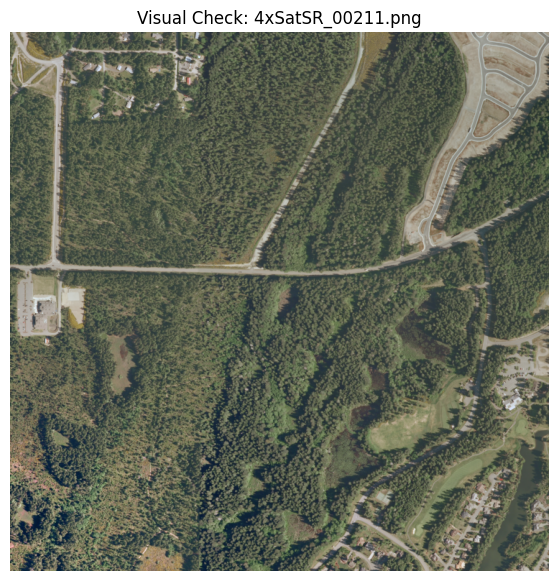

In [24]:
# 가장 첫 번째 변환된 파일(PNG)을 시각화해서 깨짐이 없는지 확인
df_test = pd.read_csv(base_csv_path)

if len(df_test) > 0:
    test_img_path = df_test.iloc[0]['png_path']
    test_img = cv2.imread(test_img_path)

    if test_img is not None:
        # OpenCV는 BGR로 읽어오므로 RGB로 변환하여 matplotlib 출력
        test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(7, 7))
        plt.imshow(test_img_rgb)
        plt.title(f"Visual Check: {df_test.iloc[0]['png_filename']}")
        plt.axis('off')
        plt.show()
    else:
        print(f"❌ {test_img_path} 경로에서 이미지를 읽을 수 없습니다.")
else:
    print("⚠️ 변환된 기록(CSV)이 비어있습니다.")

# STEP 04. 모델 A 해상도 판별 및 라우팅 (3M / 2M 등)

In [25]:
import os
import shutil
import pandas as pd
import torch
from torch.amp import autocast
from PIL import Image
from tqdm import tqdm

# ⚠️ 독립 실행을 위한 변수 안전 장치 (이전 셀에서 정의되었다면 무시됩니다)
if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if 'dir_routing' not in globals():
    dir_routing = os.path.join(os.path.dirname(dir_base_png), '2_routing')
os.makedirs(dir_routing, exist_ok=True)

# 클래스 인덱스 역방향 매핑 (학습 코드의 RESOLUTION_MAP 기반)
IDX_TO_RES = {0: '0.5M', 1: '1M', 2: '2M', 3: '3M', 4: '8M'}

# 4. 이미지 해상도 판별 및 라우팅 (Model A - DINOv3)
def classify_and_route(csv_path, model_A, transform_A):
    df = pd.read_csv(csv_path)
    resolutions = []
    print(f"🚀 DINOv3 모델을 활용한 정밀 해상도 판별 및 라우팅 시작 (대상: {len(df)}건)...")

    # 모델 평가 모드 전환 (검증용)
    model_A.eval()

    for img_path in tqdm(df['png_path'], desc="해상도 분류 중"):
        try:
            img = Image.open(img_path).convert('RGB')
            # 외부에서 주입받은 검증된 전처리(transform_A) 사용
            img_t = transform_A(img).unsqueeze(0).to(device)

            with torch.no_grad():
                # 최신 PyTorch 버전에 맞춘 amp autocast
                with autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                    outputs = model_A(img_t)
                    _, predicted = torch.max(outputs, 1)

            pred_idx = predicted.item()
            res_class = IDX_TO_RES.get(pred_idx, 'Unknown')
            resolutions.append(res_class)

        except Exception as e:
            print(f"❌ [{img_path}] 추론 중 오류 발생: {e}")
            resolutions.append('Error')

    df['resolution'] = resolutions

    # 분류된 해상도별로 라우팅 폴더 복사 및 CSV 생성
    routed_csvs = {}
    for res in df['resolution'].unique():
        if res in ['Unknown', 'Error']: continue

        # .copy()를 명시하여 SettingWithCopyWarning 방지
        res_df = df[df['resolution'] == res].copy()
        target_dir = os.path.join(dir_routing, f"res_{res}")
        os.makedirs(target_dir, exist_ok=True)

        new_paths = []
        for src_path in res_df['png_path']:
            dst_path = os.path.join(target_dir, os.path.basename(src_path))
            shutil.copy(src_path, dst_path)
            new_paths.append(dst_path)

        res_df.loc[:, 'routed_path'] = new_paths
        res_csv_path = os.path.join(dir_routing, f"routing_{res}.csv")
        res_df.to_csv(res_csv_path, index=False)
        routed_csvs[res] = res_csv_path
        print(f"📁 [{res}] 라우팅 완료: {len(res_df)}건 -> {target_dir}")

    return routed_csvs

# 실제 실행부 (models_dict가 정의되어 있어야 작동합니다)
if 'models_dict' in globals() and 'A_clf' in models_dict and 'A_transform' in models_dict:
    routed_csvs = classify_and_route(
        base_csv_path,
        models_dict['A_clf'],
        models_dict['A_transform'] # 전처리 객체 함께 전달
    )
else:
    print("⚠️ [오류] models_dict 또는 Model A(A_clf, A_transform)가 로드되지 않았습니다.")
    print("이전 셀에서 모델 로딩 코드를 먼저 실행해 주세요.")

🚀 DINOv3 모델을 활용한 정밀 해상도 판별 및 라우팅 시작 (대상: 10건)...


해상도 분류 중: 100%|██████████| 10/10 [00:01<00:00,  7.12it/s]


📁 [2M] 라우팅 완료: 2건 -> /content/drive/MyDrive/AIduo_dev/Project/Inference_data/2026-06-24/2_routing/res_2M
📁 [8M] 라우팅 완료: 5건 -> /content/drive/MyDrive/AIduo_dev/Project/Inference_data/2026-06-24/2_routing/res_8M
📁 [3M] 라우팅 완료: 3건 -> /content/drive/MyDrive/AIduo_dev/Project/Inference_data/2026-06-24/2_routing/res_3M


In [26]:
# 라우팅 결과 검증 로직
if 'routed_csvs' in globals() and routed_csvs:
    print("\n" + "="*50)
    print("✅ 라우팅 결과 무결성 검증을 시작합니다.")
    print("="*50)

    total_routed_files = 0

    for res, csv_path in routed_csvs.items():
        df_routed = pd.read_csv(csv_path)
        actual_dir = os.path.join(dir_routing, f"res_{res}")

        # 1. 폴더 내 실제 파일 개수 확인
        actual_files = [f for f in os.listdir(actual_dir) if f.endswith(('.png', '.jpg', '.tif'))]

        # 2. CSV 기록과 실제 파일 개수 비교
        csv_count = len(df_routed)
        file_count = len(actual_files)
        total_routed_files += csv_count

        match_status = "🟢 정상" if csv_count == file_count else "🔴 불일치"
        print(f"- [{res} 클래스] {match_status}")
        print(f"  └ CSV 기록 수: {csv_count}개 | 실제 폴더 파일 수: {file_count}개")

        # 3. 샘플 데이터 확인 (가장 첫 번째 파일 경로 검증)
        if csv_count > 0:
            sample_path = df_routed.iloc[0]['routed_path']
            is_exist = os.path.exists(sample_path)
            print(f"  └ 첫번째 파일 경로 정상 유무: {'✅ 확인됨' if is_exist else '❌ 찾을 수 없음'}")

    print("-" * 50)
    print(f"총 라우팅 완료된 이미지 수: {total_routed_files}건")
else:
    print("⚠️ 검증할 라우팅 결과가 없습니다. [Cell 5]를 먼저 실행하거나 모델 추론 결과를 확인하세요.")


✅ 라우팅 결과 무결성 검증을 시작합니다.
- [2M 클래스] 🟢 정상
  └ CSV 기록 수: 2개 | 실제 폴더 파일 수: 2개
  └ 첫번째 파일 경로 정상 유무: ✅ 확인됨
- [8M 클래스] 🟢 정상
  └ CSV 기록 수: 5개 | 실제 폴더 파일 수: 5개
  └ 첫번째 파일 경로 정상 유무: ✅ 확인됨
- [3M 클래스] 🟢 정상
  └ CSV 기록 수: 3개 | 실제 폴더 파일 수: 3개
  └ 첫번째 파일 경로 정상 유무: ✅ 확인됨
--------------------------------------------------
총 라우팅 완료된 이미지 수: 10건


# STEP05. 초해상도(SR) 파이프라인 (B -> C -> D 모델 순차 적용)

### STEP05-1. 공통 헬퍼 함수 및 환경 초기화

In [27]:
import os
import cv2
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 이미지 텐서 변환 헬퍼 함수
def img2tensor(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    img = torch.from_numpy(np.transpose(img, (2, 0, 1))).float().unsqueeze(0).to(device)
    return img

def tensor2img(tensor):
    # .detach()를 추가하여 그래디언트 추적이 켜져 있어도 안전하게 넘파이 변환
    img = tensor.squeeze(0).cpu().detach().clamp_(0, 1).numpy()
    img = np.transpose(img, (1, 2, 0))
    img = (img * 255.0).round().astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

def postprocess_tensor(output_tensor):
    # GPU 텐서를 CPU로 이동 및 detach
    img = output_tensor.detach().squeeze(0).cpu()
    # [0, 1] 범위로 클램핑
    img = torch.clamp(img, 0, 1)
    # [0, 255] 범위의 uint8 변환
    img = (img * 255.0).round().to(torch.uint8)
    # CHW -> HWC 변환
    img = img.permute(1, 2, 0).numpy()
    # RGB -> BGR 변환 (OpenCV 사용 시)
    if img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    return img

# 파이프라인 실행 딕셔너리 보관용 (초기화)
pipeline_history = {}
integrated_2m_records = []

### STEP05-2. Model B (3M -> 2M 통합) 단독 실행 및 검증

🔄 [3M] 해상도 이미지를 2M로 SR 업스케일링 시작 (총 3건)...


3M -> 2M SR: 100%|██████████| 3/3 [00:00<00:00, 11.22it/s]


🔄 [8M] 해상도 이미지를 2M로 SR 업스케일링 시작 (총 5건)...


8M -> 2M SR: 100%|██████████| 5/5 [00:00<00:00, 27.02it/s]


🔄 [2M] 해상도 이미지는 원본 유지 및 통합 시작 (총 2건)...
✅ Model B 통과 및 다중 해상도 2M 통합 완료


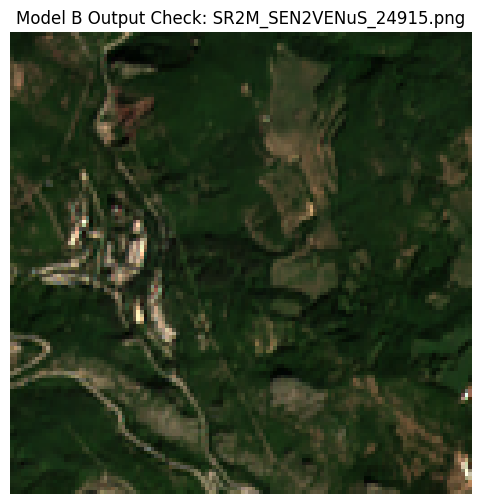

In [28]:
from tqdm import tqdm

# 5. 2M 보다 낮은 해상도(3M, 8M 등) -> 2M 통합 (Model B)
dir_2m_integrated = os.path.join(dir_routing, 'integrated_2M')
os.makedirs(dir_2m_integrated, exist_ok=True)
integrated_2m_records = []

# 💡 [수정 1] 2M로 업스케일링이 필요한 대상 해상도 클래스들을 모두 지정
target_resolutions = ['3M', '8M']

for res in target_resolutions:
    if res in routed_csvs:
        df_res = pd.read_csv(routed_csvs[res])
        print(f"🔄 [{res}] 해상도 이미지를 2M로 SR 업스케일링 시작 (총 {len(df_res)}건)...")

        for _, row in tqdm(df_res.iterrows(), total=len(df_res), desc=f"{res} -> 2M SR"):
            src_path = row['routed_path']
            filename = os.path.basename(src_path)
            out_path = os.path.join(dir_2m_integrated, f"SR2M_{filename}")

            # [수정 2] 단일 추론 환경과 동일하게 텐서 충돌을 일으키는 강제 변환 로직 제거
            img_t = img2tensor(src_path)

            # ... (앞부분 생략)
            with torch.no_grad():
                out_t = models_dict['B'](img_t)

            # [수정 3] 이미 정의해두신 tensor2img 함수를 사용하여 표준화된 변환 수행
            # 이 함수가 검은색 문제를 해결하는 핵심입니다.
            final_img = tensor2img(out_t)

            # cv2.imwrite는 BGR 포맷을 기대하며, tensor2img 함수 내에서
            # 이미 RGB->BGR 변환이 적용되어 있으므로 바로 저장하면 됩니다.
            cv2.imwrite(out_path, final_img)

            integrated_2m_records.append({'original': row['original_file'], '2m_path': out_path})
            pipeline_history[row['original_file']] = {'1_base': src_path, '2_sr2m': out_path}

# 기존 2M 파일 통합 (SR 없이 그대로 복사)
if '2M' in routed_csvs:
    df_2m = pd.read_csv(routed_csvs['2M'])
    print(f"🔄 [2M] 해상도 이미지는 원본 유지 및 통합 시작 (총 {len(df_2m)}건)...")
    path_col = 'routed_path' if 'routed_path' in df_2m.columns else 'png_path'

    for _, row in df_2m.iterrows():
        src_path = row[path_col]
        filename = os.path.basename(src_path)
        out_path = os.path.join(dir_2m_integrated, filename)

        shutil.copy(src_path, out_path)

        integrated_2m_records.append({'original': row['original_file'], '2m_path': out_path})
        pipeline_history[row['original_file']] = {'1_base': src_path, '2_sr2m': out_path}

# 결과 저장
pd.DataFrame(integrated_2m_records).to_csv(os.path.join(dir_routing, 'integrated_2M.csv'), index=False)
print("✅ Model B 통과 및 다중 해상도 2M 통합 완료")

# 🔍 [검증] Model B 결과 시각화
if integrated_2m_records:
    # 가장 마지막으로 처리된 SR 결과물을 확인하기 위해 역순 탐색
    test_record = next((r for r in reversed(integrated_2m_records) if "SR2M_" in r['2m_path']), None)
    if not test_record: test_record = integrated_2m_records[0]

    test_img = cv2.imread(test_record['2m_path'])
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(test_img)
    plt.title(f"Model B Output Check: {os.path.basename(test_record['2m_path'])}")
    plt.axis('off')
    plt.show()

### STEP05-3. Model C (2M -> 0.5M SR) 단독 실행 및 검증

✅ Model C 통과 및 0.5M 해상도 생성 완료


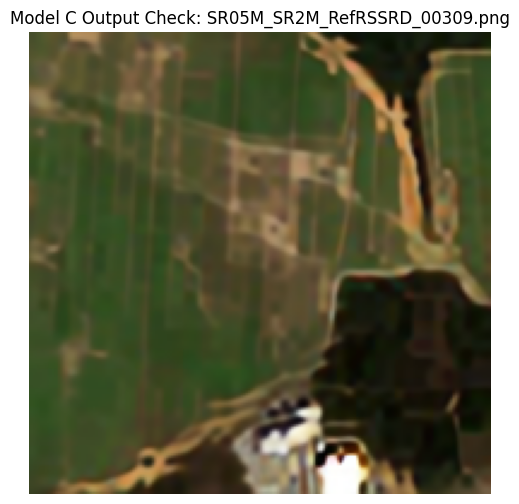

In [29]:
# 6. 2M -> 0.5M SR (Model C)
dir_05m = os.path.join(dir_routing, 'SR_0.5M')
os.makedirs(dir_05m, exist_ok=True)
model_c_records = []

for item in integrated_2m_records:
    src_path = item['2m_path']
    filename = os.path.basename(src_path)
    out_path = os.path.join(dir_05m, f"SR05M_{filename}")

    img_t = img2tensor(src_path)
    _, _, h_old, w_old = img_t.size()
    window_size = 16
    pad_h = (window_size - h_old % window_size) % window_size
    pad_w = (window_size - w_old % window_size) % window_size

    with torch.no_grad():
        if pad_h > 0 or pad_w > 0:
            img_t = F.pad(img_t, (0, pad_w, 0, pad_h), mode='reflect')

        out_t = models_dict['C'](img_t)

        scale = out_t.size(2) // img_t.size(2)
        if pad_h > 0 or pad_w > 0:
            out_t = out_t[:, :, :h_old * scale, :w_old * scale]

        new_h, new_w = int(h_old * 4), int(w_old * 4)
        if out_t.shape[2] != new_h or out_t.shape[3] != new_w:
            out_t = F.interpolate(out_t, size=(new_h, new_w), mode='bicubic', align_corners=False)

        out_t = torch.clamp(out_t, 0.0, 1.0) # 안전장치 추가

    cv2.imwrite(out_path, tensor2img(out_t))
    pipeline_history[item['original']]['3_sr05m'] = out_path
    model_c_records.append(out_path)

print("✅ Model C 통과 및 0.5M 해상도 생성 완료")

# 🔍 [검증] Model C 결과 시각화
if model_c_records:
    test_img = cv2.imread(model_c_records[0])
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(test_img)
    plt.title(f"Model C Output Check: {os.path.basename(model_c_records[0])}")
    plt.axis('off')
    plt.show()

### STEP05-4. Model D (CycleGAN 최종 개선) 단독 실행 및 검증

✅ Model D 통과 및 최종 디테일 개선 완료


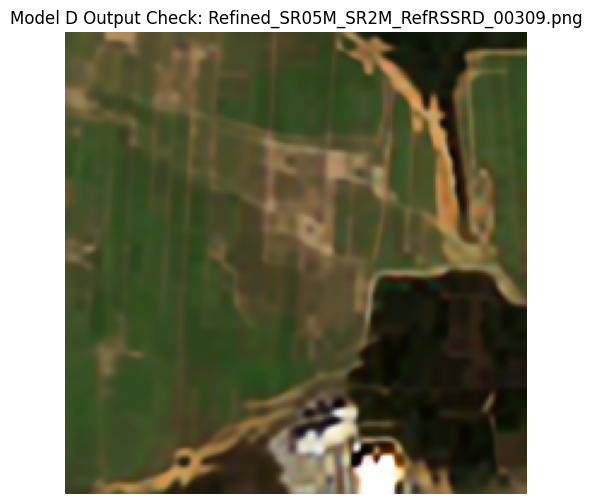

In [30]:
# 7. 0.5M -> 최종 Refinement (Model D: CycleGAN)
if 'dir_final' not in globals():
    dir_final = os.path.join(dir_routing, 'Final_Refined')
os.makedirs(dir_final, exist_ok=True)
model_d_records = []

for item in integrated_2m_records:
    src_path = pipeline_history[item['original']]['3_sr05m']
    filename = os.path.basename(src_path)
    out_path = os.path.join(dir_final, f"Refined_{filename}")

    # --- 실제 추론 시 아래 주석을 해제하세요 ---
    # img_t = img2tensor(src_path)
    # with torch.no_grad():
    #     out_t = models_dict['D'](img_t)
    #     out_t = torch.clamp(out_t, 0.0, 1.0) # 안전장치
    # cv2.imwrite(out_path, tensor2img(out_t))

    # 임시 바이패스 (테스트용)
    shutil.copy(src_path, out_path)

    pipeline_history[item['original']]['4_refined'] = out_path
    model_d_records.append(out_path)

print("✅ Model D 통과 및 최종 디테일 개선 완료")

# 🔍 [검증] Model D 결과 시각화
if model_d_records:
    test_img = cv2.imread(model_d_records[0])
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(test_img)
    plt.title(f"Model D Output Check: {os.path.basename(model_d_records[0])}")
    plt.axis('off')
    plt.show()

# STEP06. 결과 비교 시각화 (4-way View)

In [31]:
import os
import cv2
import matplotlib.pyplot as plt

# 8. 이미지 변환 과정 비교 샷 출력 (전체 뷰 + 200px 정밀 크롭 뷰)
def calculate_psnr(img1_path, img2_path):
    # GT가 있을 경우 평가 로직
    img1 = cv2.imread(img1_path).astype(np.float32)
    img2 = cv2.imread(img2_path).astype(np.float32)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0: return 100
    return 20 * np.log10(255.0 / np.sqrt(mse))


def show_comparison(history_dict, num_samples=5):
    """
    각 샘플 이미지에 대해 전체 스케일 축소 뷰와
    좌측 상단 고해상도 영역 디테일 크롭 뷰를 한 번에 출력합니다.
    """
    keys = list(history_dict.keys())[:num_samples]

    if not keys:
        print("⚠️ [시각화] 파이프라인을 통과한 이미지 이력(history)이 존재하지 않습니다.")
        return

    titles = ['1. Base Input', '2. 2M SR (Model B)', '3. 0.5M SR (Model C)', '4. Final Refined (Model D)']
    path_keys = ['1_base', '2_sr2m', '3_sr05m', '4_refined']

    for key in keys:
        paths = history_dict[key]

        # --------------------------------------------------------
        # 시각화 1: 전체 이미지 다운스케일 비교 뷰 (전체 구도 및 색감 확인)
        # --------------------------------------------------------
        fig1, axes1 = plt.subplots(1, 4, figsize=(20, 5))
        fig1.suptitle(f"📄 File: {key} - [1] 전체 이미지 파이프라인 비교", fontsize=16, fontweight='bold')

        for ax, title, pk in zip(axes1, titles, path_keys):
            if pk in paths and os.path.exists(paths[pk]):
                img = cv2.imread(paths[pk])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, 'Image Missing', ha='center', va='center')
            ax.set_title(title, fontsize=12)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

        # --------------------------------------------------------
        # 시각화 2: 좌측 상단 200px 원본 배율 크롭 뷰 (고주파 및 엣지 복원 정밀 확인)
        # --------------------------------------------------------
        fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
        fig2.suptitle(f"🔍 File: {key} - [2] 좌측 상단 200px 정밀 디테일 비교 (원본 배율)", fontsize=16, fontweight='bold')

        for ax, title, pk in zip(axes2, titles, path_keys):
            if pk in paths and os.path.exists(paths[pk]):
                img = cv2.imread(paths[pk])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # 이미지 크기가 200px보다 작을 경우를 대비한 안전 장치 추가 slice
                h, w, _ = img.shape
                crop_h = min(200, h)
                crop_w = min(200, w)

                # 좌측 상단 (0,0) 부터 가로 세로 crop 영역 추출
                cropped_img = img[0:crop_h, 0:crop_w]
                ax.imshow(cropped_img)
            else:
                ax.text(0.5, 0.5, 'Image Missing', ha='center', va='center')
            ax.set_title(f"{title} (Crop)", fontsize=12)
            ax.axis('off')

        plt.tight_layout()
        plt.show()
        print("\n" + "="*120 + "\n") # 샘플 간 경계선 분리

# ============================================================
# 시각화 스크립트 실행 (최대 5개 이미지 샘플 적용)
# ============================================================
show_comparison(pipeline_history, num_samples=5)

Output hidden; open in https://colab.research.google.com to view.